In [1]:
import pandas as pd
from glob import glob


results_list = glob("/data1/r20user3/shared_project/Hist2Cell/code/analysis/sptial_colocalization/brca/results/*.csv")
len(results_list)

630

In [2]:
results_df_list = []
for result in results_list:
    df = pd.read_csv(result, index_col=0)
    results_df_list.append(df)

In [3]:
# Concatenate the DataFrames in the list
concatenated_df = pd.concat(results_df_list, ignore_index=True)
concatenated_df

,A,B,R_val,R_z_score,R_p_val
0,IgA plasma cell,mammary gland epithelial cell,0.354121,80.911294,0.0
1,IgA plasma cell,IgG plasma cell,0.349781,79.919544,0.0
2,IgA plasma cell,neutrophil,0.329837,75.362657,0.0
3,IgG plasma cell,neutrophil,0.328028,74.949344,0.0
4,IgG plasma cell,plasmacytoid dendritic cell,0.321266,73.404434,0.0
...,...,...,...,...,...
466825,CD4-positive helper T cell,vascular associated smooth muscle cell,-0.162194,-27.395849,1.0
466826,"activated CD4-positive, alpha-beta T cell",vascular associated smooth muscle cell,-0.164132,-27.723096,1.0
466827,class switched memory B cell,vascular associated smooth muscle cell,-0.164774,-27.831517,1.0
466828,naive B cell,vascular associated smooth muscle cell,-0.168205,-28.411079,1.0


In [4]:
# Group by columns A and B and calculate the mean of each group
average_df = concatenated_df.groupby(['A', 'B']).mean().reset_index()
average_df = average_df.sort_values('R_val', ascending=False)
# 重命名列 A 和列 B 中的特定值
average_df['A'] = average_df['A'].replace({'T cell': 'proliferating T cell', 'myeloid cell': 'proliferating myeloid cell'})
average_df['B'] = average_df['B'].replace({'T cell': 'proliferating T cell', 'myeloid cell': 'proliferating myeloid cell'})
average_df

,A,B,R_val,R_z_score,R_p_val
715,neutrophil,plasmacytoid dendritic cell,0.340612,100.738441,1.588006e-03
172,IgG plasma cell,neutrophil,0.338606,99.936015,1.093772e-02
175,IgG plasma cell,plasmacytoid dendritic cell,0.335268,99.195282,1.079318e-09
666,mature NK T cell,natural killer cell,0.320879,95.231542,2.991924e-12
111,IgA plasma cell,IgG plasma cell,0.315922,94.540621,7.427729e-03
...,...,...,...,...,...
646,mammary gland epithelial cell,regulatory T cell,-0.148837,-43.495748,8.948009e-01
39,"CD4-positive, alpha-beta T cell",IgA plasma cell,-0.150683,-43.456226,8.724087e-01
136,IgA plasma cell,naive B cell,-0.150810,-43.988363,8.781561e-01
640,mammary gland epithelial cell,naive B cell,-0.155039,-45.637512,9.045077e-01


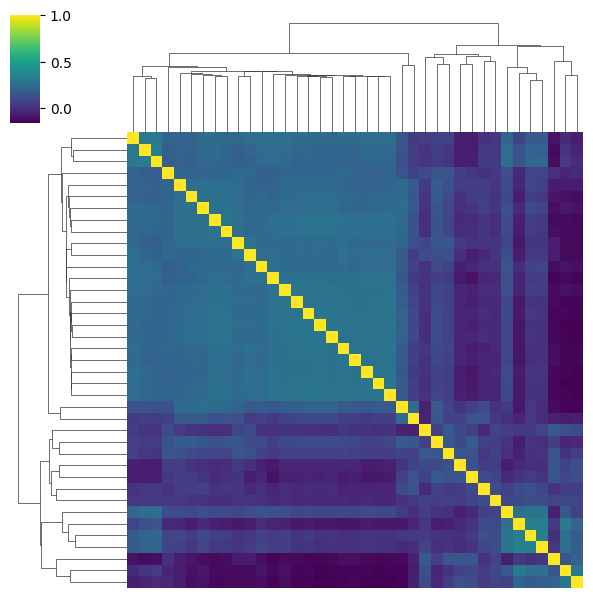

In [5]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns


df_figure = average_df[['A', 'B', 'R_val']]
correlation_df = df_figure.pivot(index="A", columns="B", values="R_val")
for var in correlation_df.index:
    correlation_df.at[var, var] = 1
    correlation_df = correlation_df.combine_first(correlation_df.T)
correlation_df.iloc[-1, -1] = 1.0
cell2location_cluster = sns.clustermap(correlation_df, figsize=(6, 6), cmap="viridis", xticklabels=False, yticklabels=False)

# 获取热图轴并调整x轴和y轴字体大小
heatmap_ax = cell2location_cluster.ax_heatmap
heatmap_ax.tick_params(axis='x', labelsize=18)  # 调整x轴字体大小
heatmap_ax.tick_params(axis='y', labelsize=18)  # 调整y轴字体大小

row_linkage = cell2location_cluster.dendrogram_row.linkage
col_linkage = cell2location_cluster.dendrogram_col.linkage
# plt.savefig("brca_overall_Hist2Cell_clustermap.svg", bbox_inches='tight', pad_inches=0)
plt.show()
plt.close()

Now, we plot the cluster map under different conditions

In [6]:
metadata = pd.read_csv("/data1/r20user3/shared_project/Hist2Cell/data/brca_clinical_from_cell_paper/brca_clinical_from_tcga.tsv", sep="\t")
metadata.head()

,case_id,case_submitter_id,project_id,age_at_index,age_is_obfuscated,cause_of_death,cause_of_death_source,country_of_residence_at_enrollment,days_to_birth,days_to_death,...,treatment_arm,treatment_dose,treatment_dose_units,treatment_effect,treatment_effect_indicator,treatment_frequency,treatment_intent_type,treatment_or_therapy,treatment_outcome,treatment_type
0,001cef41-ff86-4d3f-a140-a647ac4b10a1,TCGA-E2-A1IU,TCGA-BRCA,60,'--,'--,'--,'--,-22279,'--,...,'--,'--,'--,'--,'--,'--,'--,no,'--,"Radiation Therapy, NOS"
1,001cef41-ff86-4d3f-a140-a647ac4b10a1,TCGA-E2-A1IU,TCGA-BRCA,60,'--,'--,'--,'--,-22279,'--,...,'--,'--,'--,'--,'--,'--,'--,yes,'--,"Pharmaceutical Therapy, NOS"
2,0045349c-69d9-4306-a403-c9c1fa836644,TCGA-A1-A0SB,TCGA-BRCA,70,'--,'--,'--,'--,-25833,'--,...,'--,'--,'--,'--,'--,'--,'--,not reported,'--,"Radiation Therapy, NOS"
3,0045349c-69d9-4306-a403-c9c1fa836644,TCGA-A1-A0SB,TCGA-BRCA,70,'--,'--,'--,'--,-25833,'--,...,'--,'--,'--,'--,'--,'--,'--,not reported,'--,"Pharmaceutical Therapy, NOS"
4,00807dae-9f4a-4fd1-aac2-82eb11bf2afb,TCGA-A2-A04W,TCGA-BRCA,50,'--,'--,'--,'--,-18345,'--,...,'--,'--,'--,'--,'--,'--,'--,no,'--,"Radiation Therapy, NOS"


In [7]:
list(metadata.keys())

['case_id',
 'case_submitter_id',
 'project_id',
 'age_at_index',
 'age_is_obfuscated',
 'cause_of_death',
 'cause_of_death_source',
 'country_of_residence_at_enrollment',
 'days_to_birth',
 'days_to_death',
 'ethnicity',
 'gender',
 'occupation_duration_years',
 'premature_at_birth',
 'race',
 'vital_status',
 'weeks_gestation_at_birth',
 'year_of_birth',
 'year_of_death',
 'adrenal_hormone',
 'age_at_diagnosis',
 'ajcc_clinical_m',
 'ajcc_clinical_n',
 'ajcc_clinical_stage',
 'ajcc_clinical_t',
 'ajcc_pathologic_m',
 'ajcc_pathologic_n',
 'ajcc_pathologic_stage',
 'ajcc_pathologic_t',
 'ajcc_staging_system_edition',
 'anaplasia_present',
 'anaplasia_present_type',
 'ann_arbor_b_symptoms',
 'ann_arbor_b_symptoms_described',
 'ann_arbor_clinical_stage',
 'ann_arbor_extranodal_involvement',
 'ann_arbor_pathologic_stage',
 'best_overall_response',
 'breslow_thickness',
 'burkitt_lymphoma_clinical_variant',
 'child_pugh_classification',
 'circumferential_resection_margin',
 'classificatio

In [8]:
metadata = metadata[['case_submitter_id', 'race', 'ajcc_pathologic_stage', 'primary_diagnosis']].drop_duplicates()
metadata

,case_submitter_id,race,ajcc_pathologic_stage,primary_diagnosis
0,TCGA-E2-A1IU,white,Stage IA,"Infiltrating duct carcinoma, NOS"
2,TCGA-A1-A0SB,white,Stage I,Adenoid cystic carcinoma
4,TCGA-A2-A04W,white,Stage IIB,Apocrine adenocarcinoma
6,TCGA-AN-A0AM,white,Stage IIA,"Infiltrating duct carcinoma, NOS"
8,TCGA-LL-A440,white,Stage IA,"Lobular carcinoma, NOS"
...,...,...,...,...
2185,TCGA-A2-A0CP,white,Stage IA,"Infiltrating duct carcinoma, NOS"
2187,TCGA-PL-A8LX,black or african american,Stage IV,"Infiltrating duct carcinoma, NOS"
2189,TCGA-A2-A3XZ,black or african american,Stage I,"Infiltrating duct carcinoma, NOS"
2191,TCGA-E9-A295,white,Stage IIA,"Lobular carcinoma, NOS"


In [9]:
metadata['primary_diagnosis'].value_counts()

primary_diagnosis
Infiltrating duct carcinoma, NOS                            778
Lobular carcinoma, NOS                                      201
Infiltrating duct and lobular carcinoma                      28
Infiltrating duct mixed with other types of carcinoma        19
Mucinous adenocarcinoma                                      16
Metaplastic carcinoma, NOS                                   14
Infiltrating lobular mixed with other types of carcinoma      7
Intraductal papillary adenocarcinoma with invasion            6
Medullary carcinoma, NOS                                      6
Intraductal micropapillary carcinoma                          4
Pleomorphic carcinoma                                         3
Paget disease and infiltrating duct carcinoma of breast       3
Phyllodes tumor, malignant                                    2
Papillary carcinoma, NOS                                      2
Carcinoma, NOS                                                1
Adenoid cystic carcino

In [10]:
# 选取 'primary_diagnosis' 列值为 'Infiltrating duct carcinoma, NOS' 的行
idc_rows = metadata[metadata['primary_diagnosis'] == 'Infiltrating duct carcinoma, NOS']
# 获取这些行的 'case_submitter_id' 列的值
case_submitter_ids = list(idc_rows['case_submitter_id'])
idc_results_list = []
for item in results_list:
    for case in case_submitter_ids:
        if case in item:
            idc_results_list.append(item)
len(idc_results_list)

454

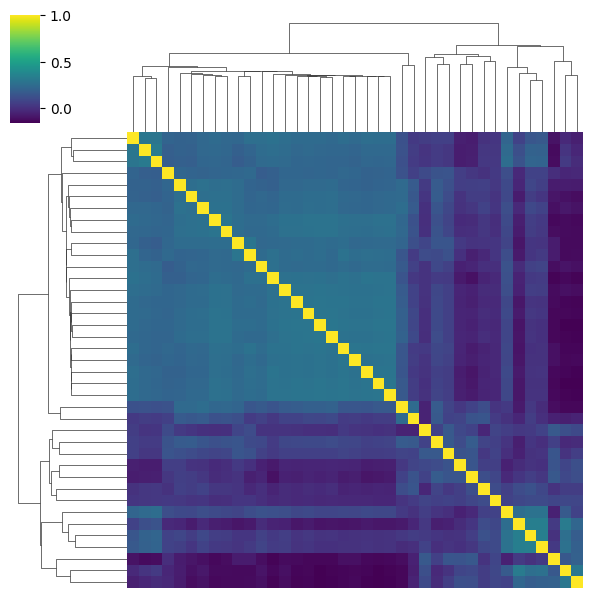

In [11]:
idc_df_list = []
for result in idc_results_list:
    df = pd.read_csv(result, index_col=0)
    idc_df_list.append(df)

# Concatenate the DataFrames in the list
concatenated_df = pd.concat(idc_df_list, ignore_index=True)

# Group by columns A and B and calculate the mean of each group
average_df = concatenated_df.groupby(['A', 'B']).mean().reset_index()
average_df = average_df.sort_values('R_val', ascending=False)
# 重命名列 A 和列 B 中的特定值
average_df['A'] = average_df['A'].replace({'T cell': 'proliferating T cell', 'myeloid cell': 'proliferating myeloid cell'})
average_df['B'] = average_df['B'].replace({'T cell': 'proliferating T cell', 'myeloid cell': 'proliferating myeloid cell'})

df_figure = average_df[['A', 'B', 'R_val']]
correlation_df = df_figure.pivot(index="A", columns="B", values="R_val")
for var in correlation_df.index:
    correlation_df.at[var, var] = 1
    correlation_df = correlation_df.combine_first(correlation_df.T)
correlation_df.iloc[-1, -1] = 1.0
cell2location_cluster = sns.clustermap(correlation_df, figsize=(6, 6), cmap="viridis", row_linkage=row_linkage, col_linkage=col_linkage, xticklabels=False, yticklabels=False)

# 获取热图轴并调整x轴和y轴字体大小
heatmap_ax = cell2location_cluster.ax_heatmap
heatmap_ax.tick_params(axis='x', labelsize=18)  # 调整x轴字体大小
heatmap_ax.tick_params(axis='y', labelsize=18)  # 调整y轴字体大小

plt.savefig("brca_idc_Hist2Cell_clustermap.svg", bbox_inches='tight', pad_inches=0)
plt.show()
plt.close()

In [12]:
correlation_df.iloc[0,1]

0.2853262420835714

In [13]:
# 选取 'primary_diagnosis' 列值为 'Infiltrating duct carcinoma, NOS' 的行
lc_rows = metadata[metadata['primary_diagnosis'] == 'Lobular carcinoma, NOS']
# 获取这些行的 'case_submitter_id' 列的值
case_submitter_ids = list(lc_rows['case_submitter_id'])
lc_results_list = []
for item in results_list:
    for case in case_submitter_ids:
        if case in item:
            lc_results_list.append(item)
len(lc_results_list)

115

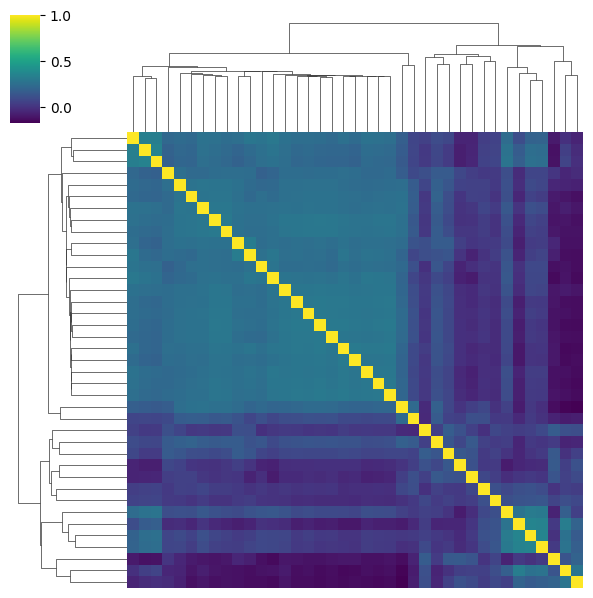

In [14]:
lc_df_list = []
for result in lc_results_list:
    df = pd.read_csv(result, index_col=0)
    lc_df_list.append(df)

# Concatenate the DataFrames in the list
concatenated_df = pd.concat(lc_df_list, ignore_index=True)

# Group by columns A and B and calculate the mean of each group
average_df = concatenated_df.groupby(['A', 'B']).mean().reset_index()
average_df = average_df.sort_values('R_val', ascending=False)
# 重命名列 A 和列 B 中的特定值
average_df['A'] = average_df['A'].replace({'T cell': 'proliferating T cell', 'myeloid cell': 'proliferating myeloid cell'})
average_df['B'] = average_df['B'].replace({'T cell': 'proliferating T cell', 'myeloid cell': 'proliferating myeloid cell'})

df_figure = average_df[['A', 'B', 'R_val']]
correlation_df = df_figure.pivot(index="A", columns="B", values="R_val")
for var in correlation_df.index:
    correlation_df.at[var, var] = 1
    correlation_df = correlation_df.combine_first(correlation_df.T)
correlation_df.iloc[-1, -1] = 1.0
cell2location_cluster = sns.clustermap(correlation_df, figsize=(6, 6), cmap="viridis", row_linkage=row_linkage, col_linkage=col_linkage, xticklabels=False, yticklabels=False)

# 获取热图轴并调整x轴和y轴字体大小
heatmap_ax = cell2location_cluster.ax_heatmap
heatmap_ax.tick_params(axis='x', labelsize=18)  # 调整x轴字体大小
heatmap_ax.tick_params(axis='y', labelsize=18)  # 调整y轴字体大小

plt.savefig("brca_lc_Hist2Cell_clustermap.svg", bbox_inches='tight', pad_inches=0)
plt.show()
plt.close()

In [15]:
correlation_df.iloc[0,1]

0.2932488796818215

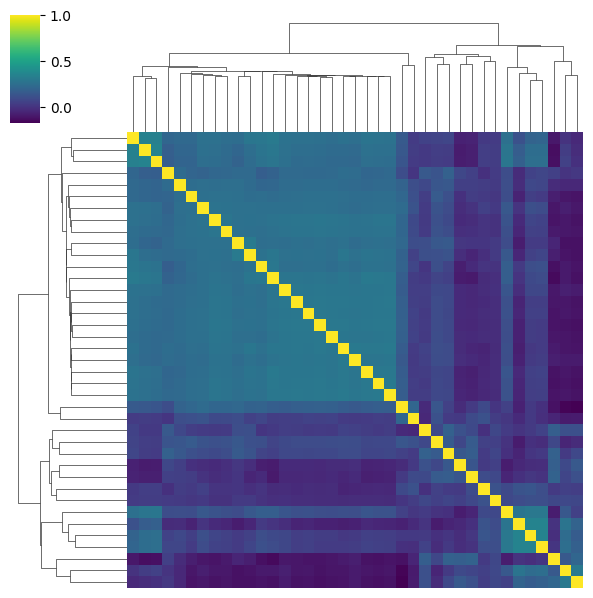

In [16]:
import random

sample_number = 32
sampled_df_list = random.sample(results_df_list, sample_number)
    
# Concatenate the DataFrames in the list
concatenated_df = pd.concat(sampled_df_list, ignore_index=True)

# Group by columns A and B and calculate the mean of each group
average_df = concatenated_df.groupby(['A', 'B']).mean().reset_index()
average_df = average_df.sort_values('R_val', ascending=False)
# 重命名列 A 和列 B 中的特定值
average_df['A'] = average_df['A'].replace({'T cell': 'proliferating T cell', 'myeloid cell': 'proliferating myeloid cell'})
average_df['B'] = average_df['B'].replace({'T cell': 'proliferating T cell', 'myeloid cell': 'proliferating myeloid cell'})

df_figure = average_df[['A', 'B', 'R_val']]
correlation_df = df_figure.pivot(index="A", columns="B", values="R_val")
for var in correlation_df.index:
    correlation_df.at[var, var] = 1
    correlation_df = correlation_df.combine_first(correlation_df.T)
correlation_df.iloc[-1, -1] = 1.0
cell2location_cluster = sns.clustermap(correlation_df, figsize=(6, 6), cmap="viridis", row_linkage=row_linkage, col_linkage=col_linkage, xticklabels=False, yticklabels=False)

# 获取热图轴并调整x轴和y轴字体大小
heatmap_ax = cell2location_cluster.ax_heatmap
heatmap_ax.tick_params(axis='x', labelsize=18)  # 调整x轴字体大小
heatmap_ax.tick_params(axis='y', labelsize=18)  # 调整y轴字体大小

plt.savefig("brca_"+str(sample_number)+"_sampled_Hist2Cell_clustermap.svg", bbox_inches='tight', pad_inches=0)
plt.show()
plt.close()

In [17]:
import random
from scipy import stats
from statsmodels.stats.multitest import multipletests
import numpy as np

sample_number = 8

sampled_df_list_1 = random.sample(results_df_list, sample_number)
sampled_df_list_2 = random.sample(results_df_list, sample_number)
    
p_value_list = []
for i in range(len(sampled_df_list[0].index)):
    moranR_list_group1 = []
    for df in sampled_df_list_1:
        moranR_list_group1.append(df.iloc[i, 2])
        
    moranR_list_group2 = []
    for df in results_df_list:
        moranR_list_group2.append(df.iloc[i, 2])
    
    # Perform t-test
    t_stat, p_value = stats.ttest_ind(np.array(moranR_list_group1), np.array(moranR_list_group2))
    p_value_list.append(p_value)

# 小于 0.05 的值的个数
count_less_than_005 = len([x for x in p_value_list if x < 0.05])
print(count_less_than_005)

56


In [18]:
len(moranR_list_group2)

630

In [19]:
p_value_list.sort()
p_value_list

[0.03477977436555347,
 0.035629431797679675,
 0.036307704715337605,
 0.03656010576037883,
 0.037452614034288526,
 0.0380508935532767,
 0.03856625436679302,
 0.03892646401935264,
 0.03899366246465231,
 0.03918670194325199,
 0.03991164635294697,
 0.04029101622084808,
 0.04041371085993223,
 0.04043220645353949,
 0.040997879294176406,
 0.0416754152687765,
 0.0416849869435355,
 0.041949032081629395,
 0.04204595364742321,
 0.042423147663725055,
 0.042434476853728705,
 0.04247047490496172,
 0.04251577654982095,
 0.04252372442841945,
 0.04277347243706691,
 0.043017870279253724,
 0.043176182190398024,
 0.04330205613979094,
 0.04335736219442747,
 0.043399234898228764,
 0.043692211881653994,
 0.043698721446202335,
 0.0438151686440765,
 0.04427638673376853,
 0.04454293581415353,
 0.044817443523433975,
 0.044936281269668796,
 0.045462130245254785,
 0.04561236848841537,
 0.045903044853419075,
 0.04650834936679258,
 0.04683341425179905,
 0.04684384589582832,
 0.04693078366691083,
 0.04699068449336845

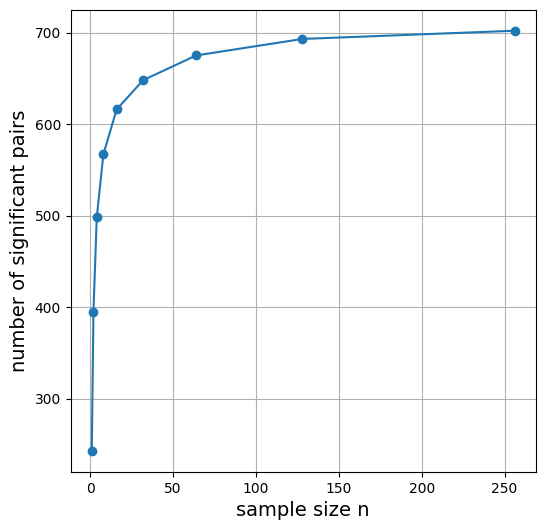

In [20]:
import matplotlib.pyplot as plt

# Your data
sample_num = [1, 2, 4, 8, 16, 32, 64, 128, 256]
sig_num = [243, 395, 498, 567, 616, 648, 675, 693, 702]

# Creating the plot
plt.figure(figsize=(6, 6))
plt.plot(sample_num, sig_num, marker='o')  # 'o' adds markers to the points

# Adding title and labels
# plt.title("Line Plot of sig_num vs. sample_num")
plt.xlabel("sample size n", fontsize=14)
plt.ylabel("number of significant pairs", fontsize=14)

# Optional: Adding grid for better readability
plt.grid(True)

# Show the plot
plt.show()

In [21]:
len(idc_df_list)

454

In [22]:
len(lc_df_list)

115

In [41]:
for df in idc_df_list:
    df['R_val_normalized'] = (df['R_val'] - df['R_val'].min()) / (df['R_val'].max() - df['R_val'].min())

In [45]:
for df in idc_df_list:
    df['R_z_score_normalized'] = (df['R_z_score'] - df['R_z_score'].min()) / (df['R_z_score'].max() - df['R_z_score'].min())

In [43]:
for df in lc_df_list:
    df['R_val_normalized'] = (df['R_val'] - df['R_val'].min()) / (df['R_val'].max() - df['R_val'].min())

In [46]:
for df in lc_df_list:
    df['R_z_score_normalized'] = (df['R_z_score'] - df['R_z_score'].min()) / (df['R_z_score'].max() - df['R_z_score'].min())

In [61]:
for df in idc_df_list:
    has_nan = df.isna().any().any()
    if has_nan:
        print("a")

In [47]:
lc_df_list[0]

,A,B,R_val,R_z_score,R_p_val,R_val_normalized,R_z_score_normalized
47,"CD4-positive, alpha-beta T cell",class switched memory B cell,0.741591,225.897862,0.0,1.000000,1.000000
65,"CD4-positive, alpha-beta T cell",naive B cell,0.739340,225.212204,0.0,0.998328,0.998328
71,"CD4-positive, alpha-beta T cell",regulatory T cell,0.739168,225.159862,0.0,0.998201,0.998201
380,class switched memory B cell,naive B cell,0.736941,224.481616,0.0,0.996547,0.996547
49,"CD4-positive, alpha-beta T cell",conventional dendritic cell,0.735945,224.178035,0.0,0.995807,0.995807
...,...,...,...,...,...,...,...
261,"activated CD8-positive, alpha-beta T cell",mammary gland epithelial cell,-0.583372,-177.702417,1.0,0.015982,0.015982
646,mammary gland epithelial cell,regulatory T cell,-0.583771,-177.823858,1.0,0.015686,0.015686
426,conventional dendritic cell,mammary gland epithelial cell,-0.587902,-179.082295,1.0,0.012617,0.012617
60,"CD4-positive, alpha-beta T cell",mammary gland epithelial cell,-0.589101,-179.447569,1.0,0.011727,0.011727


In [62]:
from math import nan
import random
from scipy import stats
import statsmodels.stats.multitest as mt
import numpy as np
from statsmodels.stats.multitest import multipletests

sample_number = 100
sampled_df_idc = random.sample(idc_df_list, sample_number)
sampled_df_lc = random.sample(lc_df_list, sample_number)
    
p_value_list = []
for i in range(len(sampled_df_idc[0].index)):
    moranR_list_group1 = []
    for df in sampled_df_idc:
        moranR_list_group1.append(df.iloc[i, 2])
        
    moranR_list_group2 = []
    for df in sampled_df_lc:
        moranR_list_group2.append(df.iloc[i, 2])
    
    # Perform t-test
    t_stat, p_value = stats.ttest_ind(np.array(moranR_list_group1), np.array(moranR_list_group2))
    # # Adjust p-values for FDR
    # p_value_list.append(p_value)

    p_value_list.append(p_value)
    
    if p_value is nan:
        print(i)


# from scipy import stats
fdr_list = stats.false_discovery_control(np.array(p_value_list))

# 小于 0.05 的值的个数
count_less_than_005 = len([x for x in fdr_list if x < 0.05])
print(count_less_than_005)

0


In [64]:
p_value_list.sort()
p_value_list

[0.022921368225978497,
 0.022958702085057466,
 0.023265413899465015,
 0.02366104866981007,
 0.023765399091254285,
 0.023983953148259834,
 0.02400838108812568,
 0.024496250469280865,
 0.024549656998571062,
 0.024551230125514082,
 0.024680248755557604,
 0.024849154396664696,
 0.02491788134695569,
 0.02534273885403515,
 0.02544388303885151,
 0.025709654142585515,
 0.025790924315172423,
 0.02611369168016096,
 0.026641437843039226,
 0.026812757831021102,
 0.02690319238271542,
 0.026912203257201932,
 0.027106964023454288,
 0.027334327749213513,
 0.027534526268146616,
 0.027606011492825374,
 0.027616786173670933,
 0.0279146160311683,
 0.02796007215069028,
 0.027996888819264595,
 0.028132557348602073,
 0.02825619093037187,
 0.02837521508711306,
 0.028590967413226084,
 0.02860811674566768,
 0.02869332959750822,
 0.0289431126177754,
 0.028948961328157243,
 0.029464483651908284,
 0.029669759460596662,
 0.02968853336195777,
 0.03002997479935156,
 0.030131464608808108,
 0.030533304796854684,
 0.030

In [97]:
import random
from scipy import stats
import statsmodels.stats.multitest as mt
import numpy as np
from statsmodels.stats.multitest import multipletests

cell_type_pair_number = len(idc_df_list[0].index)   
p_value_list = []
for i in range(1, cell_type_pair_number-1):
    moranR_list_group_idc = []
    for df in idc_df_list:
        moranR_list_group_idc.append(df.iloc[i, 6])
        
    moranR_list_group_lc = []
    for df in lc_df_list:
        moranR_list_group_lc.append(df.iloc[i, 6])
    
    # Perform t-test
    t_stat, p_value = stats.ttest_ind(np.array(moranR_list_group_idc), np.array(moranR_list_group_lc))
    p_value_list.append(p_value)
    
    if np.isnan(p_value):
        print(i)
        break


# from scipy import stats
p_adjusted = multipletests(np.array(p_value_list), method='fdr_bh')[1]

# 小于 0.05 的值的个数
count_less_than_005 = len([x for x in p_adjusted if x < 0.15])
print(count_less_than_005)

0


In [98]:
p_value_list.sort()
p_value_list

[0.059342624349582145,
 0.07935336958366342,
 0.09890317773929998,
 0.10266254249386138,
 0.1230696168895484,
 0.1231692273309437,
 0.1504529687787998,
 0.1617024266698489,
 0.16671715044992194,
 0.17013718325590194,
 0.1705333189817188,
 0.1735203402235755,
 0.17796059642287604,
 0.17854871894909158,
 0.17967091389963058,
 0.18306347005864565,
 0.18440565777494686,
 0.18535884365322128,
 0.18549252715827624,
 0.18670048353102286,
 0.1876769935624071,
 0.18997191942347788,
 0.18998877812902196,
 0.19070028761857868,
 0.19227041291371302,
 0.1931319978458815,
 0.19764718687309796,
 0.20137744815832095,
 0.2017544232614834,
 0.20249095091296856,
 0.20336483559755375,
 0.2038541912641261,
 0.20488276108613784,
 0.2049274722960743,
 0.20530296249324625,
 0.20755995750777093,
 0.20861143727301903,
 0.20920338320792248,
 0.20922519272609708,
 0.21138959477147398,
 0.2180947125851044,
 0.22306027733916653,
 0.22453499487942588,
 0.22787123862116332,
 0.22805209847642505,
 0.22884979472327757,

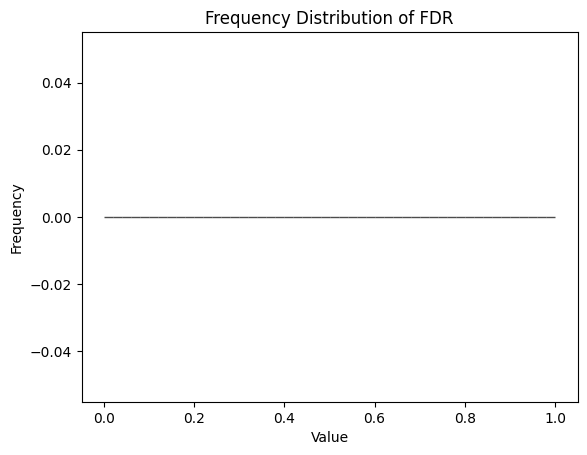

In [50]:
import numpy as np
import matplotlib.pyplot as plt

# 假设 data 是您的一维 ndarray，所有值都在 0 到 1 之间
# 例如: data = np.random.rand(1000)  # 生成 1000 个随机数作为示例

# 使用直方图显示值的频率分布
plt.hist(p_adjusted, bins=50, range=(0, 1), edgecolor='black', alpha=0.7)

# 添加标题和轴标签
plt.title('Frequency Distribution of FDR')
plt.xlabel('Value')
plt.ylabel('Frequency')

# 标注最大值和最小值
min_value = np.min(p_adjusted)
max_value = np.max(p_adjusted)
plt.annotate('Min: {:.4f}'.format(min_value), xy=(min_value, 0), xytext=(min_value, 30),
             arrowprops=dict(facecolor='black', shrink=0.05),
             horizontalalignment='center')
plt.annotate('Max: {:.4f}'.format(max_value), xy=(max_value, 0), xytext=(max_value, 30),
             arrowprops=dict(facecolor='black', shrink=0.05),
             horizontalalignment='center')

# 显示图形
plt.show()


In [26]:
import random
from scipy import stats
import statsmodels.stats.multitest as mt
import numpy as np
from statsmodels.stats.multitest import multipletests

cell_type_pair_number = len(idc_df_list[0].index)   
p_value_list = []
for i in range(cell_type_pair_number):
    moranR_list_group_idc = []
    for df in idc_df_list:
        moranR_list_group_idc.append(df.iloc[i, 2])
        
    moranR_list_group_lc = []
    for df in lc_df_list:
        moranR_list_group_lc.append(df.iloc[i, 2])
    
    # Perform t-test
    t_stat, p_value = stats.ttest_ind(np.array(moranR_list_group_idc), np.array(moranR_list_group_lc))
    p_value_list.append(p_value)


# 小于 0.05 的值的个数
count_less_than_005 = len([x for x in p_value_list if x < 0.05])
print(count_less_than_005)

173
